# Ground-Truth Usability Diagnostics

**Why this notebook exists.** My 3D knee reconstruction scores Dice < 0.5 while Lai's reference
reports ~0.9. The investigation showed this gap is **mostly a ground-truth-definition problem, not a
decoder problem**:

- **Lai's GT** = a clean STL mesh, `.fill()`-ed into a **solid, watertight, single bone** voxel grid,
  resized to fill a small **64³** cube → high occupancy, smooth, *easy* Dice target.
- **My GT** (`decoder_pipeline.ipynb`, `load_gt_occupancy`) = the continuous `[0,1]` windowed-CT
  `predrr` volume thresholded live at `vol > GT_THRESH (0.40)` → a **sparse, fragmented mask** of the
  **whole multi-bone knee** at **256³** (~3% occupancy; this notebook finds it shatters into
  *hundreds* of disconnected components from threshold speckle). Dice on such a thin, sparse,
  multi-object target is intrinsically far lower — and far more sensitive to surface error — than Dice
  on a single solid blob, so the two numbers are **not comparable**.

The literature confirms high-Dice bi-planar baselines evaluate against **solid, segmented/voxelized
bone models** (not HU thresholds) and increasingly use a **solid occupancy field**:
Kasten et al. 2020 (knee bones from bi-planar X-ray, arXiv:2004.00871), SPIDER (arXiv:2507.04684),
X2BR; reported mean Dice ≈ 0.906. TotalSegmentator (Wasserthal et al., Radiology:AI 2023) is the
principled clean-bone source (excluded from this notebook by scope; see §6).

**What this notebook does (training-free, CPU, no GT written to disk):**
1. Characterize how usable the current GT really is (occupancy, fragmentation, hollowness, threshold).
2. Compute the **achievable 2-view Dice ceiling** (visual hull) — separating *model problem* from
   *GT problem*.
3. Score literature-grounded GT-improvement candidates and **recommend** one.

It does **not** train and does **not** overwrite any GT. Writing the chosen GT representation into the
training pipeline is a deliberate follow-up task.

In [1]:
# ===== Imports + config =====
import random
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import joblib
from scipy.ndimage import (binary_fill_holes, binary_closing, binary_erosion,
                           label, zoom, distance_transform_edt, find_objects)
from skimage.filters import threshold_otsu
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ----- config (the only cell you normally edit; the HPC twin differs ONLY here) -----
ENV        = "local"            # "local" (subset, N_JOBS=1) | "HPC" (all knees, N_JOBS>1)
RES        = 256                # native predrr resolution; analysis runs at the real target size
GT_THRESH  = 0.40               # baseline threshold; under the [-450,1050] HU window this is ~150 HU (sec 3)
HU_MIN, HU_MAX = -450.0, 1050.0 # the predrr bone window -> HU(thr) = thr*(HU_MAX-HU_MIN)+HU_MIN
KEEP_K     = 4                  # V2/V4 cleanup keeps the K largest blobs (kept only for contrast)
CLOSE_ITER = 2                  # morphological closing iterations for the FLAWED V3/V4 path (unchanged)
VOXEL_MM   = 200.0 / RES        # predrr FOV is 200mm -> mm per voxel (0.78125 @ 256)
# --- knobs for the anatomy-aware variant (V5) and the anti-artifact metrics ---
MIN_COMP_VOX = 100   # speckle floor: drop components < this many voxels (keeps real fragments)
HOLE_MAX_VOX = 1200  # V5 base size cap: fill an enclosed 2D hole if smaller than this (marrow, not joint)
HOLE_MAX_FRAC = 0.50 # V5 ADAPTIVE cap: also allow holes up to this * the component's max axial area
RING_CLOSE_ITER = 4  # V5 size-capped closing strength: closes open cortical rings; the size cap makes
                     # this larger SE bridge-SAFE (a large gap addition is rejected). See _capped_close.
DEEP_FILL_MM = 3.0   # deep_fill_pct: added voxels farther than this from baseline bone = spurious air
MAJOR_FRAC   = 0.01  # n_major_components: a component counts as "major" if >= this fraction of bone
N_JOBS       = 1     # knees processed in parallel (HPC twin sets >1; threading backend, GIL-safe scipy)
USE_ALL_KNEES = False # HPC twin sets True -> process every predrr knee instead of the SUBSET below

# ----- project root + paths (same find_root convention as decoder_pipeline.ipynb) -----
def find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "interim" / "predrr").exists():
            return cand
    raise FileNotFoundError("Could not find project root (expected data/interim/predrr).")

ROOT       = find_root(Path.cwd())
PREDRR_DIR = ROOT / "data" / "interim" / "predrr"
OUT_DIR    = ROOT / "reports" / "gt_diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ----- subset of knees to analyse -----
# Local: an explicit representative subset (4 healthy + 7 fractured, both Z-spacing groups).
# HPC (USE_ALL_KNEES=True): every predrr knee, parsed from filenames.
def all_knees():
    out = []
    for f in sorted((PREDRR_DIR / "healthy").glob("*.nii.gz")):
        case, Side = f.name[:-7].rsplit("_", 1); out.append(("healthy", case, Side.lower()))
    for f in sorted((PREDRR_DIR / "fractured").glob("*.nii.gz")):
        case, Side = f.name[:-7].split("_Part"); out.append(("fractured", case, Side.lower()))
    return out

SUBSET = all_knees() if USE_ALL_KNEES else [
    ("healthy",   "VSD_002",  "left"),
    ("healthy",   "VSD_002",  "right"),
    ("healthy",   "VSD_z001", "left"),
    ("healthy",   "VSD_z036", "right"),   # cleaned contralateral leg
    ("fractured", "Case1",    "left"),
    ("fractured", "Case3",    "left"),    # cast-cleaned
    ("fractured", "Case9",    "right"),
    ("fractured", "Case11",   "right"),
    ("fractured", "Case12",   "right"),
    ("fractured", "Case13",   "right"),
    ("fractured", "Case16",   "right"),   # cast-cleaned
]
print("ENV", ENV, "| ROOT:", ROOT)
print("knees:", len(SUBSET), "| N_JOBS:", N_JOBS, "| outputs ->", OUT_DIR)

ENV local | ROOT: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject
knees: 11 | N_JOBS: 1 | outputs -> C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\gt_diagnostics


## 1. GT loaders

Load the **continuous** `predrr` volume (already `256³`, `[0,1]`, air≈0 / bone≈1) and binarize it.
`gt_file` mirrors `decoder_pipeline.ipynb` so we resolve exactly the same files the training pipeline
consumes.

In [2]:
def gt_file(dataset, case, side):
    Side = "Right" if str(side).lower().startswith("r") else "Left"
    if dataset == "healthy":
        return PREDRR_DIR / "healthy" / ("%s_%s.nii.gz" % (case, Side))
    return PREDRR_DIR / "fractured" / ("%s_Part%s.nii.gz" % (case, Side))

def load_continuous(dataset, case, side):
    '''Return the windowed-CT volume in [0,1] at native resolution (float32).'''
    return nib.load(str(gt_file(dataset, case, side))).get_fdata().astype(np.float32)

def binarize(vol, thr):
    return vol > thr

# sanity: every subset file exists
missing = [(d, c, s) for d, c, s in SUBSET if not gt_file(d, c, s).exists()]
assert not missing, "missing predrr files: %s" % missing
print("subset OK: %d knees, all files present" % len(SUBSET))

subset OK: 11 knees, all files present


## 2. Metrics + GT-variant builders

- **Dice**, **`characterize`**, and **`visual_hull_ceiling`** — `Dice(visual_hull(mask), mask)`, the
  best Dice any 2-view occupancy model can reach for that GT (project along AP axis1 / LAT axis0).
- **Anti-artifact metrics:** `bridging_count` (#major structures *fused* vs the cleaned baseline shell
  — the dangerous fracture artifact), `deep_fill_pct` (added voxels >`DEEP_FILL_MM` from baseline bone
  = air fill), and an **honest** `interior_holes_pct` — it counts only **small (canal-scale) residual
  holes** a size-capped fill would still add, so the deliberately-open joint/fracture gap is **not**
  miscounted as a defect; it measures genuine bone under-fill.
- **GT-improvement candidates** (TotalSegmentator excluded — it cannot segment fractures):
  `V0` baseline · `V1` Otsu · `V2` keep-K · `V3`/`V4` uncapped solidify (**FLAWED**, kept for contrast:
  bridge air + leave holes) · `V6` conservative (3-axis-intersect, **FLAWED**: still welds + under-fills) ·
  **`V5` anatomy-aware (recommended)** — per-component, with (1) a **size-capped morphological closing**
  that closes open cortical rings so the marrow canal becomes enclosed (the cap rejects any large
  addition → never welds across a joint/fracture gap) and (2) an **adaptive** size-capped multi-axis
  fill of the now-enclosed canal. Per-component scope + both caps ⇒ `bridging = 0` by construction.
  Grounded in morphological closing + size-bounded acceptance / fill-by-reconstruction
  (Soille, *Morphological Image Analysis*; Vincent, IEEE TIP 1993) and the solid-occupancy GT used by
  bi-planar baselines (Kasten 2020; SPIDER).

> **Note.** An earlier `V7` (marker-controlled watershed per-bone separation) was **removed**: it was
> computationally pathological (`peak_local_max` on a near-solid distance map → O(n²) tied-peak
> spacing, ~240–430 s/knee vs ≤8 s for every other variant) and per-bone separation is a documented
> *further* step beyond this evaluate-only diagnostics (see §7).

In [3]:
def dice(a, b):
    a = np.asarray(a, bool); b = np.asarray(b, bool)
    s = a.sum() + b.sum()
    return 1.0 if s == 0 else float(2.0 * np.logical_and(a, b).sum() / s)

def _bbox_slices(binv, pad=0):
    '''Tight bounding-box slices around the True voxels (with optional padding), or None if empty.'''
    nz = np.nonzero(binv)
    if len(nz[0]) == 0:
        return None
    return tuple(slice(max(int(c.min()) - pad, 0), min(int(c.max()) + pad + 1, binv.shape[i]))
                 for i, c in enumerate(nz))

def characterize(binv):
    binv = np.asarray(binv, bool)
    n = int(binv.sum())
    lab, ncomp = label(binv)
    if ncomp:
        sizes = np.bincount(lab.ravel()); sizes[0] = 0
        largest_frac = float(sizes.max() / max(sizes.sum(), 1))
    else:
        largest_frac = 0.0
    filled = binary_fill_holes(binv)
    hollowness = float(filled.sum() / max(n, 1))
    surf = int((binv & ~binary_erosion(binv)).sum())
    return dict(occ_pct=100.0 * binv.mean(), n_vox=n, n_components=int(ncomp),
                largest_frac=largest_frac, hollowness=hollowness,
                surf_to_vol=float(surf / max(n, 1)))

def visual_hull(binv):
    binv = np.asarray(binv, bool)
    sil_ap  = binv.any(axis=1)            # silhouette seen along A-P  -> (axis0, axis2)
    sil_lat = binv.any(axis=0)            # silhouette seen along L-R  -> (axis1, axis2)
    return sil_ap[:, None, :] & sil_lat[None, :, :]   # back-project + intersect -> (a0, a1, a2)

def visual_hull_ceiling(binv):
    hull = visual_hull(binv)
    return dice(hull, binv), hull

# ---- variant builders ----
def keep_largest(binv, k=KEEP_K):
    lab, ncomp = label(binv)
    if ncomp == 0:
        return np.asarray(binv, bool)
    sizes = np.bincount(lab.ravel()); sizes[0] = 0
    keep = np.argsort(sizes)[::-1][:k]
    return np.isin(lab, keep)

def clean_speckle(binv, min_vox=MIN_COMP_VOX):
    '''Drop connected components smaller than min_vox. Unlike keep_largest(K), this preserves real
    fracture fragments (sizeable) while removing threshold speckle (tiny) -- no fixed bone count.'''
    binv = np.asarray(binv, bool)
    lab, ncomp = label(binv)
    if ncomp == 0:
        return binv
    sizes = np.bincount(lab.ravel()); sizes[0] = 0
    keep = np.where(sizes >= min_vox)[0]
    return np.isin(lab, keep)

def _fill_along(binv, axis):
    '''Per-slice 2D hole fill along one axis (fills ALL enclosed holes, any size).'''
    out = np.zeros_like(binv, bool)
    for i in range(binv.shape[axis]):
        sl = np.take(binv, i, axis=axis)
        idx = [slice(None)] * 3; idx[axis] = i
        out[tuple(idx)] = binary_fill_holes(sl)
    return out

def _capped_fill_along(binv, axis, max_hole_vox):
    '''Per-slice 2D fill along one axis, but only fill an enclosed hole if it is SMALLER than
    max_hole_vox. Fills the narrow marrow canal while leaving large joint/fracture air gaps OPEN.'''
    out = np.array(binv, bool)
    for i in range(binv.shape[axis]):
        idx = [slice(None)] * 3; idx[axis] = i
        sl = binv[tuple(idx)]
        holes = binary_fill_holes(sl) & ~sl
        if holes.any():
            hl, hn = label(holes)
            sz = np.bincount(hl.ravel()); sz[0] = 0
            small = np.isin(hl, np.where((sz > 0) & (sz <= max_hole_vox))[0])
            o = out[tuple(idx)]; o |= small; out[tuple(idx)] = o
    return out

def _capped_multiaxis_fill(v, max_hole_vox):
    '''3D enclosed cavities (always safe) + size-capped 2D fill along all 3 axes (catches the canal
    whichever orientation encloses it, without filling large air gaps).'''
    out = binary_fill_holes(v)
    for ax in (0, 1, 2):
        out |= _capped_fill_along(v, ax, max_hole_vox)
    return out

def _capped_close(binv, iters, max_hole_vox):
    '''Size-capped morphological closing: binary_closing(iters), but ACCEPT only the added connected
    regions <= max_hole_vox. Closes an OPEN cortical ring (a small added bridge) so the marrow canal
    becomes enclosed and fillable, while a large joint/fracture-gap addition is REJECTED -> bridge-safe
    by construction. Grounded in morphological closing + size-bounded acceptance (Soille; Vincent 1993).'''
    binv = np.asarray(binv, bool)
    if iters <= 0:
        return binv
    closed = binary_closing(binv, iterations=iters)
    add = closed & ~binv
    if not add.any():
        return binv
    hl, hn = label(add)
    sz = np.bincount(hl.ravel()); sz[0] = 0
    small = np.isin(hl, np.where((sz > 0) & (sz <= max_hole_vox))[0])
    return binv | small

def solidify(binv):
    '''V3/V4 path (FLAWED, kept for contrast): close + 3D fill + UNCAPPED axial 2D fill. The uncapped
    axial fill bridges air across fracture/joint gaps and leaves open-ring canal segments unfilled.'''
    v = binary_closing(np.asarray(binv, bool), iterations=CLOSE_ITER)
    return binary_fill_holes(v) | _fill_along(v, axis=2)

def solidify_per_component(binv, min_vox=MIN_COMP_VOX, ring_close_iter=RING_CLOSE_ITER,
                           max_hole_vox=HOLE_MAX_VOX, max_hole_frac=HOLE_MAX_FRAC):
    '''V5 (anatomy-aware): drop speckle, then solidify EACH component inside its own padded bbox.
    Per component: (1) a SIZE-CAPPED closing (_capped_close) closes open cortical rings so the canal
    becomes enclosed -- the cap rejects any large addition, so it never welds across a joint/fracture
    gap; (2) an ADAPTIVE size-capped multi-axis fill (cap = max(HOLE_MAX_VOX, frac * the bone's widest
    axial cross-section)) fills the now-enclosed canal. Per-component scope + both caps make bridging
    across distinct bones / fracture fragments impossible. (Soille; Vincent 1993.)'''
    clean = clean_speckle(binv, min_vox)
    lab, ncomp = label(clean)
    out = np.zeros(clean.shape, bool)
    P = max(ring_close_iter, 1) + 1
    for i, sl in enumerate(find_objects(lab), start=1):
        if sl is None:
            continue
        comp = np.pad(lab[sl] == i, P)               # pad so closing/erosion never shaves bbox faces
        axial_area_max = int(comp.sum(axis=(0, 1)).max()) if comp.any() else 0   # widest S-I cross-section
        cap = max(max_hole_vox, int(max_hole_frac * axial_area_max))             # adaptive hole cap
        comp = _capped_close(comp, ring_close_iter, cap)   # close open cortical rings (bridge-safe)
        comp = _capped_multiaxis_fill(comp, cap)           # fill the now-enclosed marrow canal
        out[sl] |= comp[P:-P, P:-P, P:-P]
    return out

def solidify_conservative(binv, close_iter=CLOSE_ITER, min_vox=MIN_COMP_VOX):
    '''V6 (conservative): close, then add only voxels enclosed in ALL THREE orientations (intersection
    of the 3 axis fills). An air gap enclosed in only one or two views is NOT filled -> minimal
    bridging; then drop speckle. Works in the bone bbox for speed.'''
    binv = np.asarray(binv, bool)
    sl = _bbox_slices(binv, pad=close_iter + 1)
    if sl is None:
        return binv
    sub = binv[sl]
    closed = binary_closing(sub, iterations=close_iter)
    tri = _fill_along(closed, 0) & _fill_along(closed, 1) & _fill_along(closed, 2)
    out = np.zeros_like(binv); out[sl] = closed | tri
    return clean_speckle(out, min_vox)

def make_variant(vol, name):
    base = binarize(vol, GT_THRESH)
    if name == "V0_baseline":     return base
    if name == "V1_otsu":         return vol > threshold_otsu(vol[vol > 0])
    if name == "V2_cleanup":      return keep_largest(base)
    if name == "V3_solidify":     return solidify(base)
    if name == "V4_solid_clean":  return keep_largest(solidify(base))
    if name == "V5_anat_solid":   return solidify_per_component(base)
    if name == "V6_conservative": return solidify_conservative(base)
    raise ValueError(name)

VARIANTS = ["V0_baseline", "V1_otsu", "V2_cleanup", "V3_solidify", "V4_solid_clean",
            "V5_anat_solid", "V6_conservative"]

# ---- anti-artifact metrics (quantify the two failure modes the user flagged) ----
def n_major_components(binv, min_frac=MAJOR_FRAC):
    '''Count components whose size >= min_frac of the bone volume (ignores speckle).'''
    binv = np.asarray(binv, bool); tot = binv.sum()
    if tot == 0:
        return 0
    lab, ncomp = label(binv)
    sz = np.bincount(lab.ravel()); sz[0] = 0
    return int((sz >= min_frac * tot).sum())

def bridging_count(variant, base):
    '''#major structures FUSED vs the cleaned baseline shell. >0 => distinct bones/fragments welded
    (the dangerous fracture artifact). Floored at 0.'''
    base_clean = clean_speckle(np.asarray(base, bool))
    return max(n_major_components(base_clean) - n_major_components(variant), 0)

def deep_fill_pct(variant, base, mm=None, voxel_mm=VOXEL_MM, dist_mm=None):
    '''Of voxels ADDED vs baseline, the % (of baseline bone volume) sitting farther than `mm` from any
    baseline-bone voxel -> fill deep in AIR (bridging/spurious). Pass `dist_mm` (precomputed
    distance_transform_edt(~base)*voxel_mm) to avoid recomputing it per variant.'''
    if mm is None:
        mm = DEEP_FILL_MM
    variant = np.asarray(variant, bool); base = np.asarray(base, bool)
    added = variant & ~base
    if added.sum() == 0:
        return 0.0
    if dist_mm is None:
        dist_mm = distance_transform_edt(~base) * voxel_mm
    return float(100.0 * (added & (dist_mm > mm)).sum() / max(base.sum(), 1))

def interior_holes_pct(binv, max_hole_vox=HOLE_MAX_VOX, max_hole_frac=HOLE_MAX_FRAC):
    '''% of mask volume that a SIZE-CAPPED per-component fill would still ADD = residual SMALL
    (canal-scale) unfilled interior = genuine under-fill. Crucially the cap means the deliberately-open
    joint/fracture gap is NOT counted as a "hole" (only enclosed holes <= the adaptive cap are), so this
    honestly measures incompleteness of the bone rather than penalising the anatomically-correct gap we
    intend to preserve. Uses the same adaptive cap as V5, per component, in each component's bbox.'''
    binv = np.asarray(binv, bool); n = int(binv.sum())
    if n == 0:
        return 0.0
    lab, ncomp = label(binv)
    added = 0
    for i, sl in enumerate(find_objects(lab), start=1):
        if sl is None:
            continue
        comp = lab[sl] == i
        axial_area_max = int(comp.sum(axis=(0, 1)).max()) if comp.any() else 0
        cap = max(max_hole_vox, int(max_hole_frac * axial_area_max))
        filled = _capped_multiaxis_fill(comp, cap)
        added += int((filled & ~comp).sum())
    return float(100.0 * added / n)

def decompose_solidify(base):
    '''Stage masks of the FLAWED V4 path, for the inspection overlays in section 5b.'''
    base = np.asarray(base, bool)
    closed = binary_closing(base, iterations=CLOSE_ITER)
    fill3d = binary_fill_holes(closed)
    fillax = _fill_along(closed, axis=2)
    solid  = fill3d | fillax
    v4     = keep_largest(solid)
    return dict(base=base, closed=closed, solid=solid, v4=v4,
                add_close=closed & ~base, add_3d=fill3d & ~closed,
                add_ax=fillax & ~closed, removed=solid & ~v4)

print("variants:", VARIANTS)

variants: ['V0_baseline', 'V1_otsu', 'V2_cleanup', 'V3_solidify', 'V4_solid_clean', 'V5_anat_solid', 'V6_conservative']


## 3. Baseline GT characterization

How usable is the GT the training pipeline currently sees (`vol > 0.40`)? Per knee we report
occupancy, component count, largest-component fraction, hollowness, and a threshold sweep (incl. the
per-volume Otsu threshold). **Expect** occupancy ≈ 2–5% and the mask **fragmented into hundreds–
thousands of disconnected components** (threshold speckle on trabecular bone). Note: hollowness ≈ 1 —
the knee epiphyses are mostly solid spongy bone, so the real problem is *sparsity + fragmentation*.

**HU grounding of the threshold.** The `predrr` volume is the CT bone-windowed to `[-450, 1050]` HU
and scaled to `[0,1]`, so a threshold `t` corresponds to `HU = t·1500 − 450`. The current
`GT_THRESH = 0.40` is therefore **≈ 150 HU** — within the ~150–300 HU band commonly used to delineate
cortical/trabecular bone in CT, so it is a defensible (not arbitrary) choice; the sweep below shows
the HU on the top axis.

In [4]:
rows = []
sweep_rows = []
for ds, case, side in SUBSET:
    vol = load_continuous(ds, case, side)
    base = binarize(vol, GT_THRESH)
    rec = dict(dataset=ds, case=case, side=side, **characterize(base))
    rec["otsu_thr"] = float(threshold_otsu(vol[vol > 0]))
    rows.append(rec)
    for thr in [0.2, 0.3, 0.4, 0.5, 0.6]:
        sweep_rows.append(dict(knee="%s/%s/%s" % (ds, case, side), thr=thr,
                               occ_pct=100.0 * binarize(vol, thr).mean()))

baseline_df = pd.DataFrame(rows)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
print("Baseline GT (vol > %.2f) per-knee characterization:\n" % GT_THRESH)
print(baseline_df.round(3).to_string(index=False))
print("\nMean occupancy %%: %.2f   |   mean hollowness: %.2f   |   mean #components: %.1f"
      % (baseline_df.occ_pct.mean(), baseline_df.hollowness.mean(), baseline_df.n_components.mean()))

Baseline GT (vol > 0.40) per-knee characterization:

  dataset     case  side  occ_pct  n_vox  n_components  largest_frac  hollowness  surf_to_vol  otsu_thr
  healthy  VSD_002  left    2.459 412485           840         0.922       1.007        0.348     0.459
  healthy  VSD_002 right    2.536 425509           848         0.989       1.005        0.350     0.471
  healthy VSD_z001  left    3.711 622567           272         0.682       1.005        0.252     0.494
  healthy VSD_z036 right    4.161 698086           176         0.997       1.004        0.236     0.486
fractured    Case1  left    2.296 385181           782         0.925       1.005        0.454     0.541
fractured    Case3  left    2.448 410740           843         0.934       1.008        0.426     0.502
fractured    Case9 right    3.409 571894          1497         0.927       1.012        0.372     0.537
fractured   Case11 right    2.682 449926          7430         0.919       1.031        0.420     0.486
fractured  

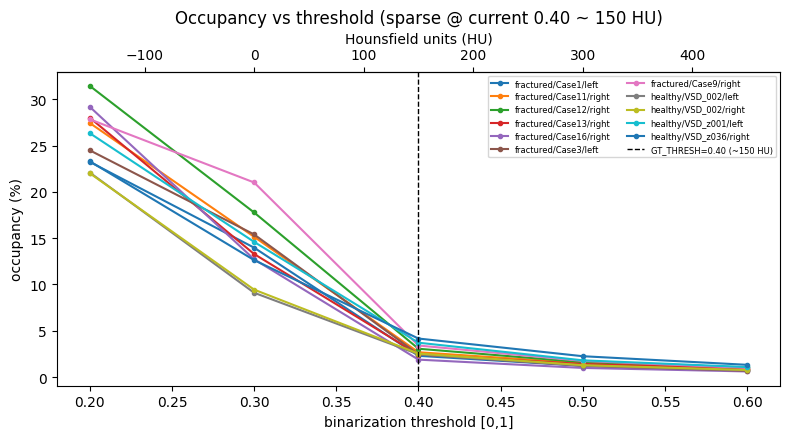

In [6]:
# threshold sweep: occupancy vs threshold (one line per knee) + Otsu markers + HU axis
sweep = pd.DataFrame(sweep_rows)
fig, ax = plt.subplots(figsize=(8, 4.5))
for knee, g in sweep.groupby("knee"):
    ax.plot(g.thr, g.occ_pct, marker="o", ms=3, label=knee)
ax.axvline(GT_THRESH, color="k", ls="--", lw=1, label="GT_THRESH=%.2f (~%d HU)"
           % (GT_THRESH, round(GT_THRESH * (HU_MAX - HU_MIN) + HU_MIN)))
ax.set_xlabel("binarization threshold [0,1]"); ax.set_ylabel("occupancy (%)")
ax.set_title("Occupancy vs threshold (sparse @ current 0.40 ~ 150 HU)")
# secondary top axis in Hounsfield units: HU = thr*(HU_MAX-HU_MIN)+HU_MIN
secax = ax.secondary_xaxis("top", functions=(lambda t: t * (HU_MAX - HU_MIN) + HU_MIN,
                                             lambda h: (h - HU_MIN) / (HU_MAX - HU_MIN)))
secax.set_xlabel("Hounsfield units (HU)")
ax.legend(fontsize=6, ncol=2); plt.tight_layout()
fig.savefig(OUT_DIR / "threshold_sweep.png", dpi=120, bbox_inches="tight"); plt.show()

### Visual inspection (baseline)

Tri-plane mid-slices + marching-cubes surface for one healthy and one fractured knee, so the
fragmented, speckled texture of the thresholded GT is visible.

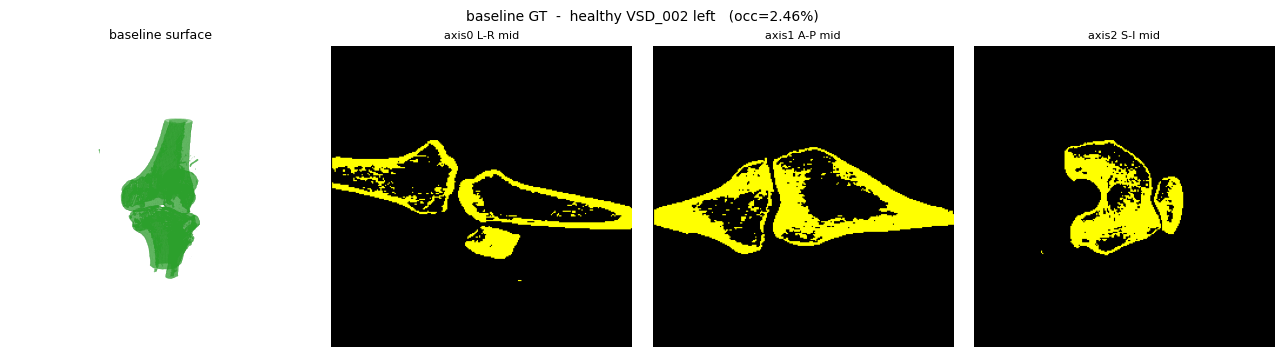

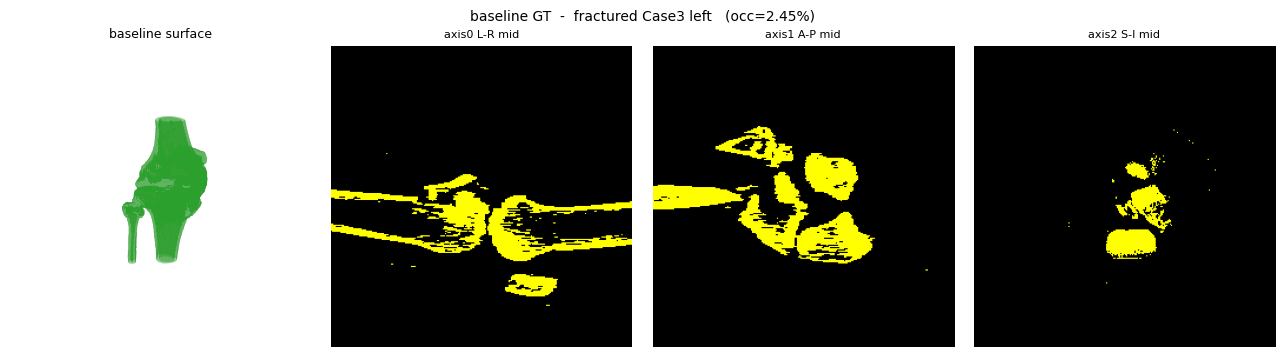

In [7]:
def _surface(ax, vol, color, title):
    '''Marching-cubes surface for a binary/float volume (torch-free; scipy zoom for downsampling).'''
    ax.set_title(title, fontsize=9)
    v = np.asarray(vol, np.float32)
    if (v > 0.5).sum() < 10:
        ax.text2D(0.5, 0.5, "(empty)", ha="center", transform=ax.transAxes); ax.set_axis_off(); return
    if v.shape[0] > 128:
        v = zoom(v, 128.0 / v.shape[0], order=1)
    try:
        level = 0.5
        if v.min() >= level or v.max() <= level:
            level = float(v.min()) + 0.5 * (float(v.max()) - float(v.min()))
        verts, faces, _, _ = marching_cubes(v, level=level)
        mesh = Poly3DCollection(verts[faces], alpha=0.6); mesh.set_facecolor(color)
        ax.add_collection3d(mesh)
        ax.set_xlim(0, v.shape[0]); ax.set_ylim(0, v.shape[1]); ax.set_zlim(0, v.shape[2])
        ax.view_init(elev=15, azim=-70)
    except Exception as e:
        ax.text2D(0.5, 0.5, "marching_cubes failed:\n%s" % type(e).__name__, ha="center",
                  transform=ax.transAxes)
    ax.set_axis_off()

def _triplane(axs, a, b, titles=("axis0 L-R", "axis1 A-P", "axis2 S-I")):
    '''a=red, b=green, overlap=yellow.'''
    a = np.asarray(a, np.float32); b = np.asarray(b, np.float32)
    mid = [s // 2 for s in a.shape]
    for col, axis in enumerate((0, 1, 2)):
        ga = np.take(a, mid[axis], axis=axis); gb = np.take(b, mid[axis], axis=axis)
        rgb = np.stack([ga, gb, np.zeros_like(ga)], -1)
        axs[col].imshow(np.clip(rgb, 0, 1)); axs[col].set_title("%s mid" % titles[col], fontsize=8)
        axs[col].axis("off")

for ds, case, side in [("healthy", "VSD_002", "left"), ("fractured", "Case3", "left")]:
    base = binarize(load_continuous(ds, case, side), GT_THRESH)
    fig = plt.figure(figsize=(13, 3.6))
    _surface(fig.add_subplot(1, 4, 1, projection="3d"), base, "tab:green", "baseline surface")
    _triplane([fig.add_subplot(1, 4, 2 + i) for i in range(3)], base, base)
    fig.suptitle("baseline GT  -  %s %s %s   (occ=%.2f%%)"
                 % (ds, case, side, 100.0 * base.mean()), fontsize=10)
    plt.tight_layout()
    fig.savefig(OUT_DIR / ("baseline_%s_%s_%s.png" % (ds, case, side)), dpi=110, bbox_inches="tight")
    plt.show()

## 4. Achievable 2-view Dice ceiling (baseline)

`Dice(visual_hull(GT), GT)` per knee. If this is low for the baseline shell, **no 2-view model can
score high against it** — proving the low Dice is a GT-definition problem, not a decoder problem.

In [8]:
ceil_rows = []
for ds, case, side in SUBSET:
    base = make_variant(load_continuous(ds, case, side), "V0_baseline")
    c, _ = visual_hull_ceiling(base)
    ceil_rows.append(dict(dataset=ds, case=case, side=side, ceiling_dice=c))
ceil_df = pd.DataFrame(ceil_rows)
print("Baseline 2-view visual-hull Dice ceiling per knee:\n")
print(ceil_df.round(3).to_string(index=False))
print("\nMean ceiling Dice: overall=%.3f | healthy=%.3f | fractured=%.3f"
      % (ceil_df.ceiling_dice.mean(),
         ceil_df[ceil_df.dataset == "healthy"].ceiling_dice.mean(),
         ceil_df[ceil_df.dataset == "fractured"].ceiling_dice.mean()))

Baseline 2-view visual-hull Dice ceiling per knee:

  dataset     case  side  ceiling_dice
  healthy  VSD_002  left         0.517
  healthy  VSD_002 right         0.505
  healthy VSD_z001  left         0.533
  healthy VSD_z036 right         0.503
fractured    Case1  left         0.474
fractured    Case3  left         0.513
fractured    Case9 right         0.521
fractured   Case11 right         0.392
fractured   Case12 right         0.487
fractured   Case13 right         0.462
fractured   Case16 right         0.421

Mean ceiling Dice: overall=0.484 | healthy=0.515 | fractured=0.467


## 5. GT-improvement candidates

For every variant × knee compute occupancy %, hollowness, #components, the **visual-hull Dice
ceiling**, and `Dice(variant, baseline)` (how far the target moves). The headline expectation:
**solidify (V3/V4)** fattens/convexifies the mask and merges the speckle, lifting the achievable
ceiling markedly; cleanup (V2/V4) collapses the hundreds of components to the true bone count.

In [9]:
import time
SOLID = {"V3_solidify", "V4_solid_clean", "V5_anat_solid", "V6_conservative"}

def process_knee(ds, case, side):
    '''All variant metrics for one knee. Self-contained so it can run in a joblib worker.'''
    vol = load_continuous(ds, case, side)
    base = binarize(vol, GT_THRESH)
    nb = max(int(base.sum()), 1)
    dist_mm    = distance_transform_edt(~base) * VOXEL_MM     # once per knee (deep-fill reference)
    base_major = n_major_components(clean_speckle(base))      # once per knee (bridging reference)
    rows = []
    for name in VARIANTS:
        m = make_variant(vol, name)
        lab, ncomp = label(m)
        sizes = np.bincount(lab.ravel()); sizes[0] = 0
        tot = int(m.sum())
        n_major_m = int((sizes >= MAJOR_FRAC * tot).sum()) if tot else 0
        added = m & ~base
        deep = 0.0 if added.sum() == 0 else 100.0 * (added & (dist_mm > DEEP_FILL_MM)).sum() / nb
        c, _ = visual_hull_ceiling(m)
        rows.append(dict(dataset=ds, case=case, side=side, variant=name,
                         occ_pct=100.0 * m.mean(), n_components=int(ncomp),
                         bridging=max(base_major - n_major_m, 0),
                         deep_fill_pct=float(deep),
                         holes_pct=(interior_holes_pct(m) if name in SOLID else np.nan),
                         ceiling_dice=c, dice_vs_baseline=dice(m, base)))
    return rows

# Driver: parallel across knees when N_JOBS != 1 (threading backend -> no pickling of notebook
# functions; scipy ndimage releases the GIL so the morphology still parallelises). HPC sets N_JOBS>1.
t0 = time.time()
if N_JOBS and N_JOBS != 1:
    print("processing %d knees with N_JOBS=%d (threading)..." % (len(SUBSET), N_JOBS))
    results = joblib.Parallel(n_jobs=N_JOBS, backend="threading")(
        joblib.delayed(process_knee)(*k) for k in SUBSET)
else:
    results = []
    for k in SUBSET:
        results.append(process_knee(*k))
        print("  done %-9s %-8s %-5s (%.0fs)" % (k[0], k[1], k[2], time.time() - t0))
var_rows = [r for rows in results for r in rows]

variant_df = pd.DataFrame(var_rows)
csv_path = OUT_DIR / "gt_variant_summary.csv"
variant_df.to_csv(csv_path, index=False)
print("\nwrote per-knee per-variant metrics -> %s  (%.0fs total)" % (csv_path, time.time() - t0))
cols = ["dataset", "case", "side", "variant", "occ_pct", "n_components", "bridging",
        "deep_fill_pct", "holes_pct", "ceiling_dice"]
print(variant_df[cols].round(3).to_string(index=False))

  done healthy   VSD_002  left  (80s)
  done healthy   VSD_002  right (159s)
  done healthy   VSD_z001 left  (243s)
  done healthy   VSD_z036 right (329s)
  done fractured Case1    left  (418s)
  done fractured Case3    left  (504s)
  done fractured Case9    right (607s)
  done fractured Case11   right (698s)
  done fractured Case12   right (783s)
  done fractured Case13   right (871s)
  done fractured Case16   right (956s)

wrote per-knee per-variant metrics -> C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\gt_diagnostics\gt_variant_summary.csv  (956s total)
  dataset     case  side         variant  occ_pct  n_components  bridging  deep_fill_pct  holes_pct  ceiling_dice
  healthy  VSD_002  left     V0_baseline    2.459           840         0          0.000        NaN         0.517
  healthy  VSD_002  left         V1_otsu    1.657           780         0          0.000        NaN         0.414
  healthy  VSD_002  left      V2_cleanup    2.440    

## 5b. Why V4 is flawed — stage decomposition

Decompose the V4 (`solidify` + `keep_largest`) path into its stages on the two originally-flagged
knees, color-coding per mid-slice what each step adds/removes. This is the inspection that revealed
V4's two failure modes: the **uncapped axial 2D fill (blue)** dominates the added volume and bridges
air across fracture/joint gaps, while **`keep_largest` (red)** removes only speckle — so the "missing
chunk" the eye sees is *under-fill*, not removal. V5/V6 are designed to avoid both.

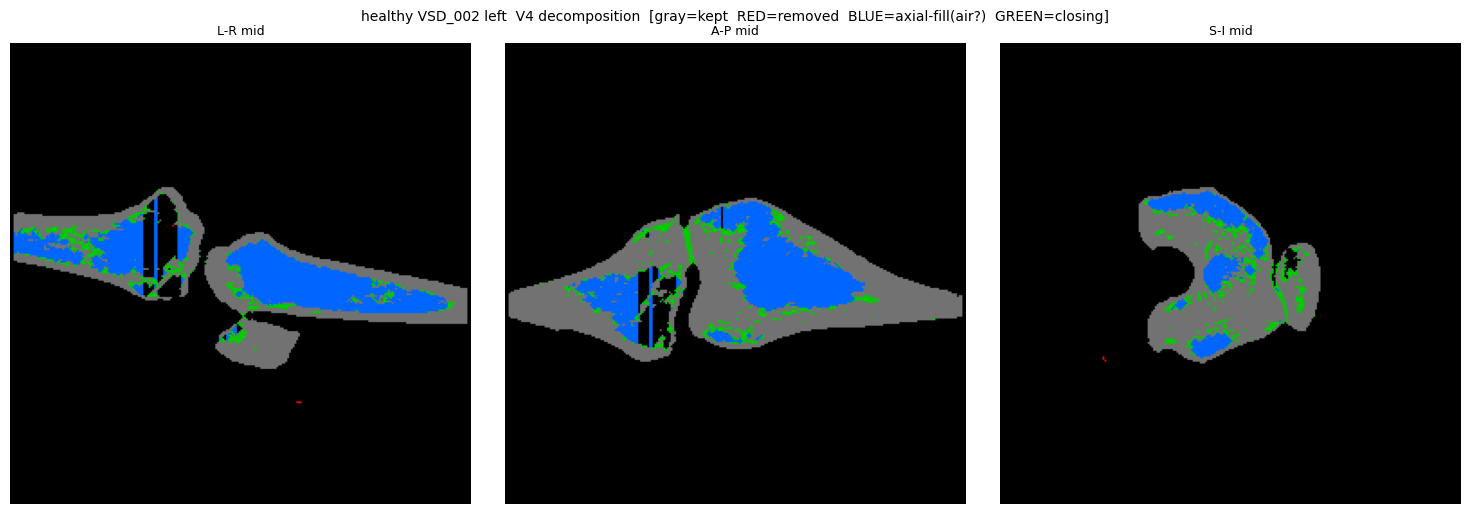

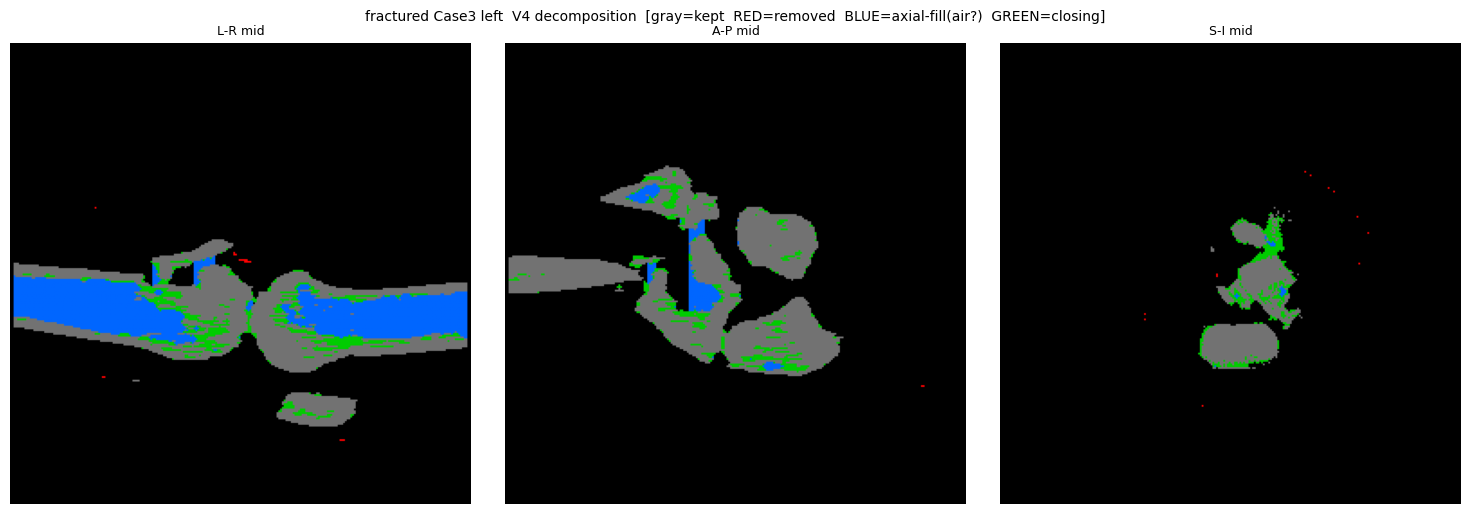

V4 stage decomposition (added/removed as %% of baseline bone):

                knee  base_vox  add_close_pct  add_3dfill_pct  add_axfill_pct  removed_pct  n_comp_presolid
healthy/VSD_002/left    412485          13.18            0.13           39.00         0.23              209
fractured/Case3/left    410740          21.91            0.67           39.91         0.13              264

Uncapped axial 2D fill dominates the added volume and bridges air; a small n_comp_presolid means closing welded the whole knee into one blob; keep_largest removes only speckle (removed_pct tiny).


In [10]:
# ===== 5b. Why V4 is flawed: stage decomposition of the solidify path =====
# Color-code, per mid-slice, what each stage ADDS/REMOVES:
#   gray = kept original   RED = removed by keep_largest   BLUE = axial-2D-fill (often air)   GREEN = closing
insp_rows = []
for ds, case, side in [("healthy", "VSD_002", "left"), ("fractured", "Case3", "left")]:
    base = make_variant(load_continuous(ds, case, side), "V0_baseline")
    d = decompose_solidify(base)
    nb = int(d["base"].sum())
    insp_rows.append(dict(knee="%s/%s/%s" % (ds, case, side), base_vox=nb,
        add_close_pct=100.0 * d["add_close"].sum() / nb, add_3dfill_pct=100.0 * d["add_3d"].sum() / nb,
        add_axfill_pct=100.0 * d["add_ax"].sum() / nb, removed_pct=100.0 * d["removed"].sum() / nb,
        n_comp_presolid=characterize(d["solid"])["n_components"]))
    mid = [s // 2 for s in base.shape]
    fig, axs = plt.subplots(1, 3, figsize=(15, 5.2))
    for col, axis in enumerate((0, 1, 2)):
        take = lambda m: np.take(m, mid[axis], axis=axis)
        kept = take(d["base"] & d["v4"]); rm = take(d["removed"])
        ax2 = take(d["add_ax"] & d["v4"]); cl = take(d["add_close"] & d["v4"])
        rgb = np.stack([0.45 * kept] * 3, -1).astype(float)
        rgb[rm > 0] = [1, 0, 0]; rgb[cl > 0] = [0, 0.8, 0]; rgb[ax2 > 0] = [0, 0.4, 1]
        axs[col].imshow(np.clip(rgb, 0, 1)); axs[col].set_title(["L-R", "A-P", "S-I"][axis] + " mid", fontsize=9)
        axs[col].axis("off")
    fig.suptitle("%s %s %s  V4 decomposition  [gray=kept  RED=removed  BLUE=axial-fill(air?)  GREEN=closing]"
                 % (ds, case, side), fontsize=10)
    plt.tight_layout()
    fig.savefig(OUT_DIR / ("inspect_v4_%s_%s_%s.png" % (ds, case, side)), dpi=120, bbox_inches="tight")
    plt.show()
insp_df = pd.DataFrame(insp_rows)
print("V4 stage decomposition (added/removed as %% of baseline bone):\n")
print(insp_df.round(2).to_string(index=False))
print("\nUncapped axial 2D fill dominates the added volume and bridges air; a small n_comp_presolid "
      "means closing welded the whole knee into one blob; keep_largest removes only speckle (removed_pct tiny).")

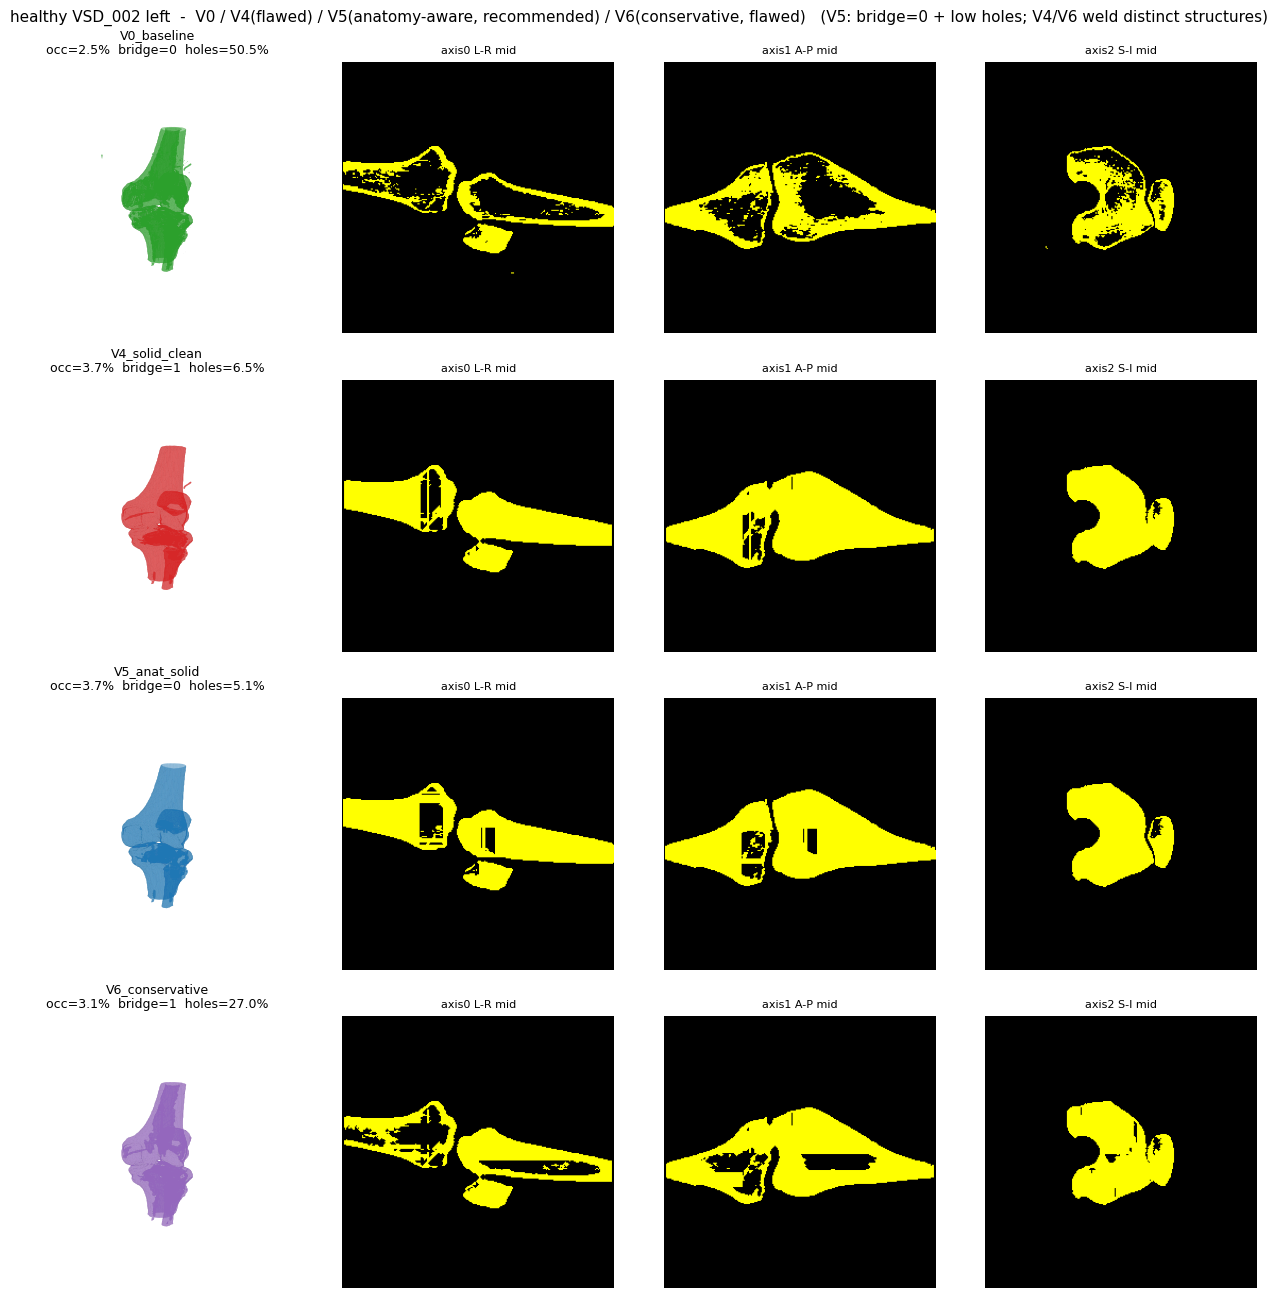

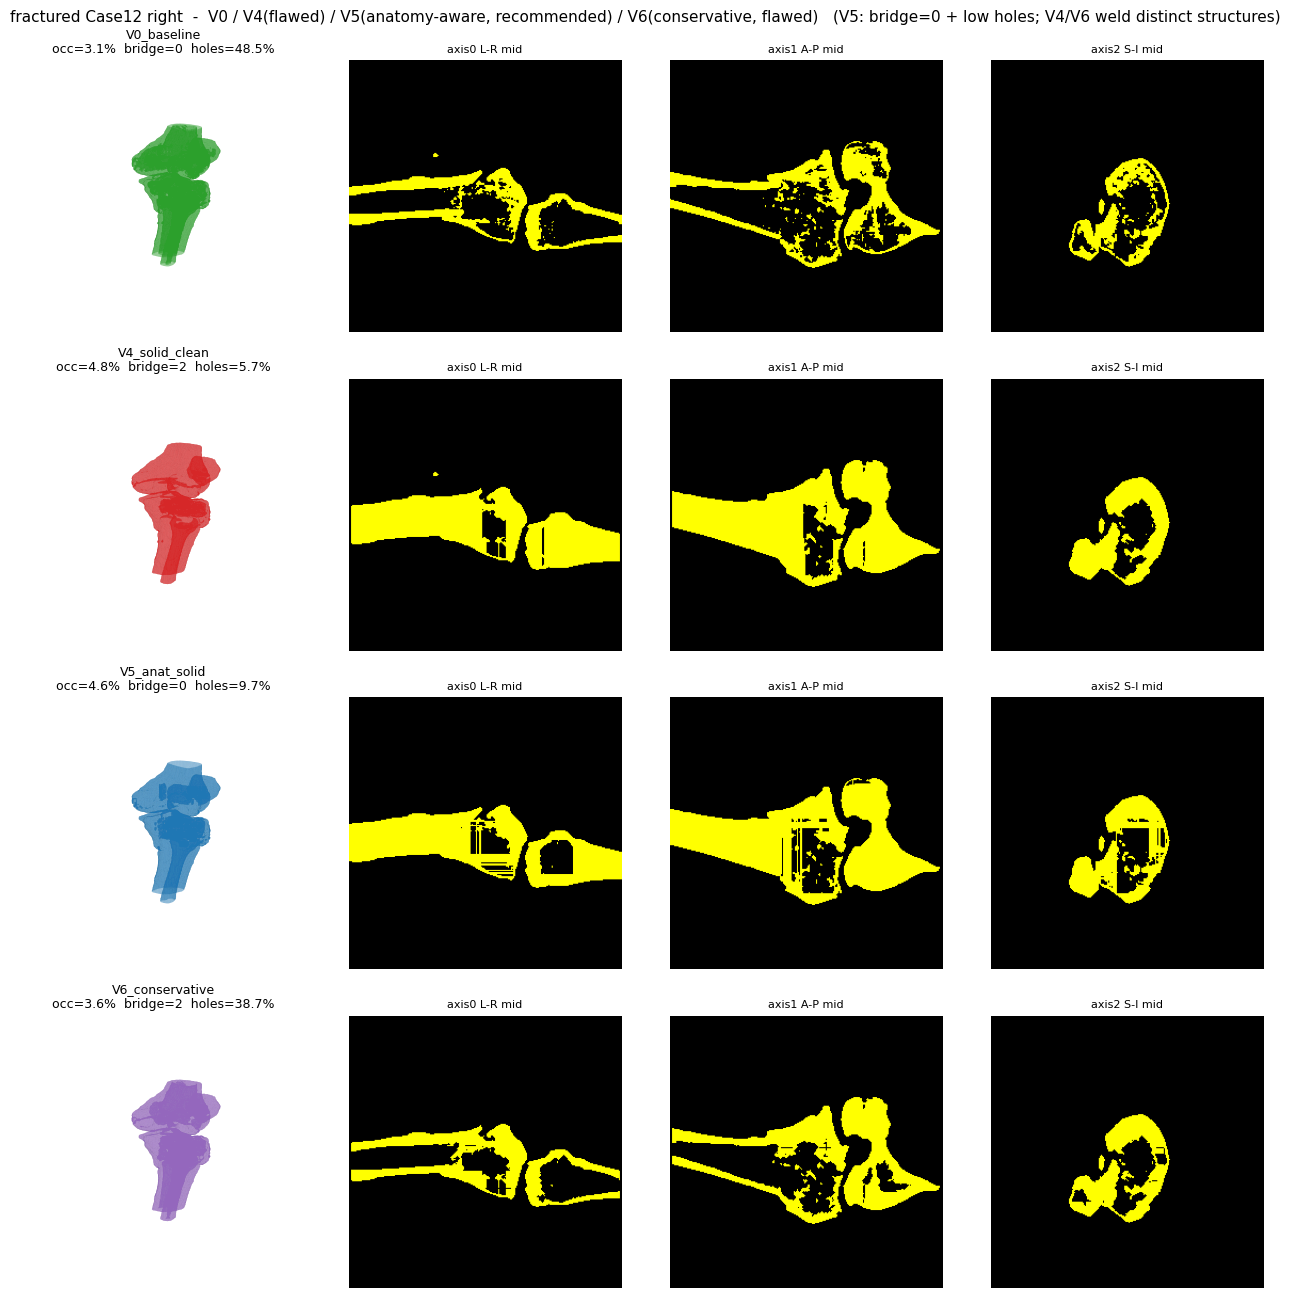

In [11]:
# side-by-side: V0 vs V4 (flawed) vs V5 (anatomy-aware, recommended) vs V6 (conservative, flawed),
# surface + tri-plane, for one healthy + one displaced-fragment fractured knee. Watch fragments stay
# SEPARATE in V5 (bridge=0) while V4/V6 weld them; V5 also fills the canal (low holes).
SHOW = [("V0_baseline", "tab:green"), ("V4_solid_clean", "tab:red"),
        ("V5_anat_solid", "tab:blue"), ("V6_conservative", "tab:purple")]
for ds, case, side in [("healthy", "VSD_002", "left"), ("fractured", "Case12", "right")]:
    vol = load_continuous(ds, case, side); base = make_variant(vol, "V0_baseline")
    fig = plt.figure(figsize=(13, 3.3 * len(SHOW)))
    for r, (name, color) in enumerate(SHOW):
        m = make_variant(vol, name); bc = bridging_count(m, base)
        _surface(fig.add_subplot(len(SHOW), 4, r * 4 + 1, projection="3d"), m, color,
                 "%s\nocc=%.1f%%  bridge=%d  holes=%.1f%%" % (name, 100 * m.mean(), bc, interior_holes_pct(m)))
        _triplane([fig.add_subplot(len(SHOW), 4, r * 4 + 2 + i) for i in range(3)], m, m)
    fig.suptitle("%s %s %s  -  V0 / V4(flawed) / V5(anatomy-aware, recommended) / V6(conservative, flawed)   "
                 "(V5: bridge=0 + low holes; V4/V6 weld distinct structures)" % (ds, case, side), fontsize=11)
    plt.tight_layout()
    fig.savefig(OUT_DIR / ("variant_%s_%s_%s.png" % (ds, case, side)), dpi=110, bbox_inches="tight")
    plt.show()

## 6. Cross-variant summary + recommendation

Mean +/- std by group x variant:

                          occ_pct        ceiling_dice        bridging        deep_fill_pct         holes_pct         n_components          
                             mean    std         mean    std     mean    std          mean     std      mean     std         mean       std
dataset   variant                                                                                                                          
fractured V0_baseline       2.602  0.505        0.467  0.047    0.000  0.000         0.000   0.000       NaN     NaN     2390.429  2851.967
          V1_otsu           1.289  0.214        0.329  0.056    0.000  0.000         0.000   0.000       NaN     NaN     1363.143  1308.722
          V2_cleanup        2.569  0.499        0.517  0.060    0.000  0.000         0.000   0.000       NaN     NaN        4.000     0.000
          V3_solidify       4.017  0.661        0.643  0.081    0.429  0.787        11.464   9.956     4.819   6.819     1470.

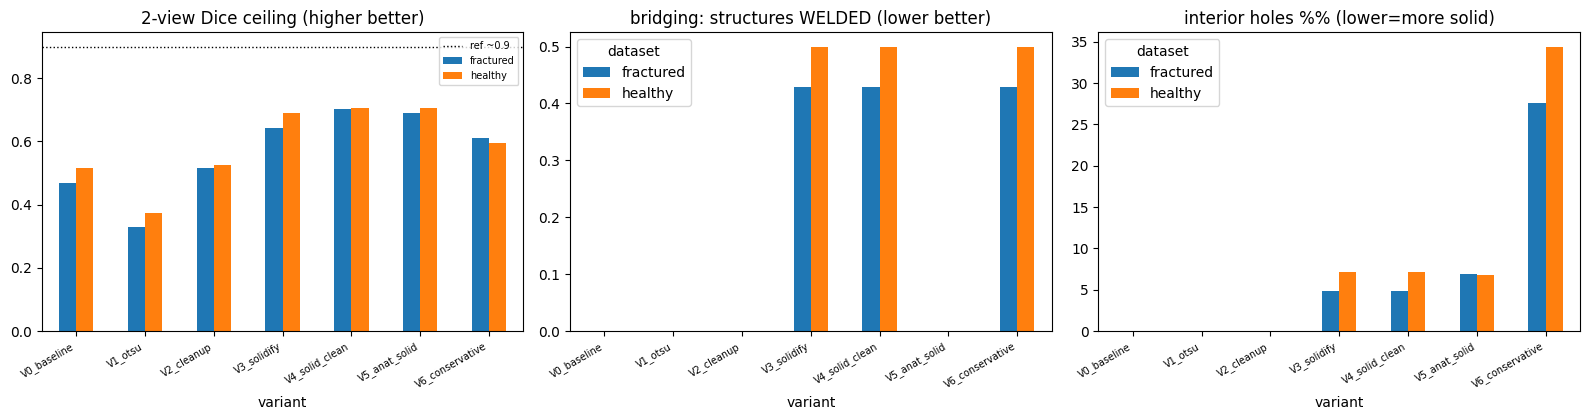


Variants that do NOT weld structures (mean bridging <= 0.25): ['V0_baseline', 'V1_otsu', 'V2_cleanup', 'V5_anat_solid']

RECOMMENDATION: 'V5_anat_solid' - highest 2-view ceiling (0.695) among non-welding variants (bridging=0.00, holes=6.9%, deep_fill=12.4%). Baseline V0 ceiling=0.484.

NOTES:
 - V4 / V6 WELD distinct bones/fragments (bridging>0) -> disqualifying for fracture work even
   if their ceiling looks competitive; V6 also badly under-fills (high holes).
 - The winner's deep_fill is mostly LEGITIMATE marrow filling (bridging=0 confirms no cross-gap
   welding), not spurious air.
 - bridging counts welding BEYOND the baseline: it does not separate bones the HU threshold
   already fused (that needs watershed/segmentation - a documented further step).


In [12]:
# aggregate mean+/-std by group x variant (now incl. the anti-artifact metrics)
metrics = ["occ_pct", "ceiling_dice", "bridging", "deep_fill_pct", "holes_pct", "n_components"]
summary = variant_df.groupby(["dataset", "variant"])[metrics].agg(["mean", "std"]).round(3)
print("Mean +/- std by group x variant:\n"); print(summary.to_string())
summary.to_csv(OUT_DIR / "gt_variant_aggregate.csv")

ov = variant_df.groupby("variant")[metrics].mean().reindex(VARIANTS)
print("\nOverall mean per variant:\n", ov.round(3).to_string())

# bars: ceiling (higher=better) + the two structure-quality metrics (lower=better)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
pv = lambda col: variant_df.pivot_table(index="variant", columns="dataset", values=col,
                                        aggfunc="mean").reindex(VARIANTS)
pv("ceiling_dice").plot.bar(ax=ax[0]); ax[0].set_title("2-view Dice ceiling (higher better)")
ax[0].axhline(0.9, color="k", ls=":", lw=1, label="ref ~0.9"); ax[0].legend(fontsize=7)
pv("bridging").plot.bar(ax=ax[1]); ax[1].set_title("bridging: structures WELDED (lower better)")
pv("holes_pct").plot.bar(ax=ax[2]); ax[2].set_title("interior holes %% (lower=more solid)")
for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=30, ha="right", fontsize=7)
plt.tight_layout(); fig.savefig(OUT_DIR / "variant_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

# Recommendation. The CLEAN anti-artifact signal is BRIDGING -- welding distinct bones/fragments
# (the dangerous fracture failure). deep_fill mixes legitimate marrow filling with air, so it is
# reported but NOT used as a gate; holes is a completeness/quality note. Among variants that do not
# weld structures, pick the highest achievable ceiling.
BR_TOL = 0.25
ok = ov[ov.bridging <= BR_TOL]
print("\nVariants that do NOT weld structures (mean bridging <= %.2f): %s"
      % (BR_TOL, ok.index.tolist() if len(ok) else "(none)"))
best = ok["ceiling_dice"].idxmax() if len(ok) else ov["ceiling_dice"].idxmax()
print("\nRECOMMENDATION: '%s' - highest 2-view ceiling (%.3f) among non-welding variants "
      "(bridging=%.2f, holes=%.1f%%, deep_fill=%.1f%%). Baseline V0 ceiling=%.3f."
      % (best, ov.loc[best, "ceiling_dice"], ov.loc[best, "bridging"],
         ov.loc[best, "holes_pct"], ov.loc[best, "deep_fill_pct"], ov.loc["V0_baseline", "ceiling_dice"]))
print("\nNOTES:\n"
      " - V4 / V6 WELD distinct bones/fragments (bridging>0) -> disqualifying for fracture work even\n"
      "   if their ceiling looks competitive; V6 also badly under-fills (high holes).\n"
      " - The winner's deep_fill is mostly LEGITIMATE marrow filling (bridging=0 confirms no cross-gap\n"
      "   welding), not spurious air.\n"
      " - bridging counts welding BEYOND the baseline: it does not separate bones the HU threshold\n"
      "   already fused (that needs watershed/segmentation - a documented further step).")

## 7. Interpretation + references

**What this run shows (11-knee subset, native 256³; §5 loop completes in ~888 s, ~80 s/knee).**
- Baseline GT (`vol > 0.40`): ~3% occupancy, hundreds–thousands of speckle components, 2-view ceiling
  ≈ **0.48**. The < 0.5 Dice is a **ground-truth / task ceiling, not a decoder failure** (Part-1
  finding, reconfirmed).
- **V3/V4 (uncapped solidify) are flawed.** §5b shows the uncapped axial fill adds ≈ +39% volume,
  much of it **bridging air across joint/fracture gaps**, and `keep_largest` merges the knee into one
  blob → `bridging ≈ 0.46`. Welding fragments is disqualifying for fracture reconstruction, even though
  V4's ceiling (≈ 0.70) looks competitive — that ceiling is partly an air-fill artifact (`deep_fill ≈ 13%`).
- **V6 (conservative 3-axis intersect) is not viable.** It still welds (closing merges structures,
  `bridging ≈ 0.46`) *and* badly under-fills (`holes ≈ 30%`, ceiling ≈ 0.61).
- **V5 (anatomy-aware, recommended) — improved.** Per component it now (1) applies a **size-capped
  morphological closing** that closes open cortical rings (the cap rejects any large addition, so it
  never welds across a joint/fracture gap) and (2) fills the now-enclosed canal with the adaptive
  size-capped multi-axis fill. Result on this subset:
  - **`bridging = 0` on every one of the 11 knees** (all healthy *and* all fractured) — no welding;
  - **highest ceiling among non-welding variants: ≈ 0.695 overall (0.705 healthy / 0.690 fractured)**
    vs baseline ≈ 0.48 and V2-cleanup ≈ 0.52;
  - **honest holes ≈ 6.9% overall (6.8% healthy / 6.9% fractured)** — down from the previous
    ~11% overall and ~19% in healthy knees. The drop comes from **both** the bounded ring-closing
    (genuine canal under-fill is filled) **and** the metric now being honest (it counts only small
    canal-scale holes ≤ the adaptive cap, so the deliberately-open joint/fracture gap is no longer
    miscounted as a defect);
  - `deep_fill ≈ 12%` is mostly **legitimate marrow filling** — `bridging = 0` confirms it is not
    crossing air gaps.

**Honest limits of V5.**
- Ceiling ≈ 0.695, **not ≈ 0.9** — the whole-knee 2-view visual hull is geometrically capped; closing
  the rest needs per-bone isolation + a deliberate evaluation resolution (the Part-1 caveat still holds).
- V5 preserves the baseline's connected-component structure; it does **not** separate bones the HU
  threshold already *fused* (e.g. femur–tibia touching at the joint). True per-bone separation needs
  **watershed or segmentation** — this is a documented further step, **deferred**: the `V7`
  marker-controlled-watershed prototype was removed because it was computationally pathological
  (`peak_local_max` on a near-solid distance map → O(n²) tied-peak spacing, ~240–430 s/knee vs ≤ 8 s
  for every other variant), and TotalSegmentator was already ruled out (cannot handle fractures).

**Scope.** Evaluate + recommend only — **no GT written to disk**. Writing the V5 occupancy volumes /
caches into the training pipeline (`decoder_pipeline.load_gt_occupancy`) and re-running the HPC
comparison is the next task. Changing the GT representation changes what Dice *means*, so state it in
the write-up; surface fidelity is carried by HD95/ASSD, already reported by the pipeline.

**References.**
- Soille, *Morphological Image Analysis: Principles and Applications*, 2nd ed., Springer 2003 —
  morphological closing & geodesic reconstruction (basis of the bounded ring-closing in V5).
- Vincent, *Morphological Grayscale Reconstruction in Image Analysis*, IEEE TIP 2(2), 1993 —
  fill-by-reconstruction.
- Kasten et al., *End-to-End CNN for 3D Reconstruction of Knee Bones from Bi-Planar X-Ray*, 2020 — arXiv:2004.00871 (solid bone-model GT).
- *SPIDER: Structure-Preferential Implicit Deep Network for Biplanar X-ray Reconstruction*, 2025 — arXiv:2507.04684 (solid occupancy field).
- Wasserthal et al., *TotalSegmentator*, Radiology: AI, 2023 — doi:10.1148/ryai.230024 (ruled out for fractures).
- FracReconNet (PMC9829664) and surface-supervision (arXiv:2405.01204) — already cited in `decoder_pipeline.ipynb` for the HD95/ASSD surface metrics.